# 🎯 Customer Segmentation Using RFM & K-Means

## End-to-End Customer Segmentation Project

### Business Scenario

A UK-based online retailer wants to move from generic marketing campaigns to **customer-specific targeting**. The objective is to identify groups of customers with similar purchasing behavior using **Recency, Frequency, and Monetary (RFM)** analysis and K-Means clustering.

### Business Objective

Build a reproducible customer segmentation workflow that can answer:

- Who are the most recently active customers?
- Who purchases frequently?
- Who generates the highest monetary value?
- Which customers are valuable and loyal?
- Which customers show lower engagement or value?
- How many customers belong to each behavioral segment?

### Project Workflow

`Raw Transactions → Data Quality → Cleaning → RFM → Distribution Analysis → Transformation → Scaling → Model Selection → K-Means → Cluster Profiling → Business Segments → Export`

> **Decision:** This notebook is designed as the complete analytical layer of the project. Production code, model artifacts, and the Streamlit application should live outside the notebook in the project repository.

## 1. Why RFM?

RFM summarizes customer purchase behavior using three dimensions:

| Metric | Meaning | Business interpretation |
|---|---|---|
| **Recency** | Days since the customer's latest purchase | Lower is generally better |
| **Frequency** | Number of distinct invoices/purchases | Higher generally indicates stronger engagement |
| **Monetary** | Total customer revenue | Higher indicates greater historical value |

### Decision

We use **behavioral RFM features rather than demographic attributes** because the supplied notebook and project objective focus on transaction history. This also makes the segmentation directly actionable for marketing analysis.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.decomposition import PCA

RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Transaction Dataset

The original notebook uses `OnlineRetail.csv`, the UK online retail transaction dataset.

### Decision

The notebook keeps the same dataset and core terminology as the original analysis, while adding explicit validation so that downstream calculations do not silently operate on a malformed file.

In [2]:
DATA_PATH = Path("OnlineRetail.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}. "
        "Place OnlineRetail.csv in the same directory as this notebook."
    )

df = pd.read_csv(DATA_PATH, encoding="unicode_escape")

print(f"Shape: {df.shape}")
display(df.head())
display(df.info())

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26,3.39,"17,850.00",United Kingdom


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.6 MB


None

## 3. Initial Data Quality Audit

Before calculating RFM, inspect:

- data types
- missing values
- duplicate rows
- unique customers
- unique invoices
- date range
- quantity and price ranges
- cancellation indicators

### Decision

We perform the audit **before cleaning** so that every cleaning decision is based on observable data rather than assumptions.

In [3]:
# Basic structure
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print(f"\nDuplicate rows: {df.duplicated().sum():,}")

print("\nUnique invoices:", df["InvoiceNo"].nunique(dropna=True))
print("Unique customers:", df["CustomerID"].nunique(dropna=True))

print("\nDate range:")
print(df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

print("\nQuantity summary:")
display(df["Quantity"].describe())

print("\nUnitPrice summary:")
display(df["UnitPrice"].describe())

Data types:


InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


Missing values:


CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64


Duplicate rows: 5,268

Unique invoices: 25900
Unique customers: 4372

Date range:
01/04/2011 10:00 to 9/30/2011 9:45

Quantity summary:


count   541,909.00
mean          9.55
std         218.08
min     -80,995.00
25%           1.00
50%           3.00
75%          10.00
max      80,995.00
Name: Quantity, dtype: float64


UnitPrice summary:


count   541,909.00
mean          4.61
std          96.76
min     -11,062.06
25%           1.25
50%           2.08
75%           4.13
max      38,970.00
Name: UnitPrice, dtype: float64

In [4]:
# Check the required columns explicitly
required_columns = [
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country",
]

missing_required = [c for c in required_columns if c not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("All required columns are present.")

All required columns are present.


## 4. Parse Dates and Identify Transaction Types

The original notebook converts `InvoiceDate` to datetime. We retain that logic and make it explicit.

Invoices beginning with `C` represent cancellations in this dataset.

### Decision

Cancelled transactions should not contribute to positive customer purchase behavior. We therefore identify them before constructing the modeling dataset.

In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df["InvoiceNo"] = df["InvoiceNo"].astype(str).str.strip()

df["IsCancellation"] = df["InvoiceNo"].str.upper().str.startswith("C")

print("Invalid InvoiceDate values:", df["InvoiceDate"].isna().sum())
print("Cancellation rows:", df["IsCancellation"].sum())

Invalid InvoiceDate values: 0
Cancellation rows: 9288


## 5. Transaction Cleaning

The modeling dataset should represent completed purchases rather than returns/cancellations or mathematically invalid transactions.

Cleaning rules:

1. Remove rows without `CustomerID`.
2. Remove invalid dates.
3. Remove cancellations.
4. Keep only positive `Quantity`.
5. Keep only positive `UnitPrice`.
6. Remove exact duplicate rows.

### Decision

This is a deliberate **business-data cleaning step**, not merely a technical cleanup. RFM is intended to describe customer purchase behavior, so negative quantities and cancelled invoices should not inflate or distort customer value.

In [6]:
rows_before = len(df)

clean_df = df.copy()

clean_df = clean_df.dropna(subset=["CustomerID", "InvoiceDate"])
clean_df = clean_df.loc[~clean_df["IsCancellation"]]
clean_df = clean_df.loc[clean_df["Quantity"] > 0]
clean_df = clean_df.loc[clean_df["UnitPrice"] > 0]
clean_df = clean_df.drop_duplicates()

clean_df["CustomerID"] = clean_df["CustomerID"].astype(int)

clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

rows_after = len(clean_df)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {rows_after:,}")
print(f"Rows removed:         {rows_before - rows_after:,}")
print(f"Retention rate:       {rows_after / rows_before:.2%}")

Rows before cleaning: 541,909
Rows after cleaning:  392,692
Rows removed:         149,217
Retention rate:       72.46%


In [7]:
display(clean_df.head())

print("Customers:", clean_df["CustomerID"].nunique())
print("Invoices:", clean_df["InvoiceNo"].nunique())
print("Countries:", clean_df["Country"].nunique())

display(clean_df[["Quantity", "UnitPrice", "Revenue"]].describe())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


Customers: 4338
Invoices: 18532
Countries: 37


,Quantity,UnitPrice,Revenue
count,"392,692.00","392,692.00","392,692.00"
mean,13.12,3.13,22.63
std,180.49,22.24,311.10
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,12.45
75%,12.00,3.75,19.80
max,"80,995.00","8,142.75","168,469.60"


## 6. Define the RFM Reference Date

Recency measures the number of days since the customer's latest purchase.

### Decision

Instead of manually choosing an arbitrary date, use **one day after the latest valid transaction date** as the observation/reference date. This is reproducible and avoids giving a zero-day recency to customers who purchased on the final observation date.

This differs slightly from the original notebook's hard-coded `2012-01-01` reference date; the data-driven reference is preferable for a reusable analytical pipeline.

In [8]:
reference_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Latest transaction:", clean_df["InvoiceDate"].max())
print("Reference date:", reference_date)

Latest transaction: 2011-12-09 12:50:00
Reference date: 2011-12-10 12:50:00


## 7. Construct RFM Features

Definitions used in this project:

- **Recency:** days between the reference date and the customer's latest invoice date.
- **Frequency:** number of distinct invoices associated with the customer.
- **Monetary:** total revenue generated by the customer.

### Decision

Frequency is based on **distinct invoices**, not transaction rows. This prevents multiple line items from the same invoice from being incorrectly interpreted as multiple purchase occasions.

In [9]:
rfm = (
    clean_df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum"),
    )
    .reset_index()
)

print("RFM shape:", rfm.shape)
display(rfm.head())
display(rfm.describe())

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,"77,183.60"
1,12347,2,7,"4,310.00"
2,12348,75,4,"1,797.24"
3,12349,19,1,"1,757.55"
4,12350,310,1,334.40


,CustomerID,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00","4,338.00"
mean,"15,300.41",92.54,4.27,"2,048.69"
std,"1,721.81",100.01,7.70,"8,985.23"
min,"12,346.00",1.00,1.00,3.75
25%,"13,813.25",18.00,1.00,306.48
50%,"15,299.50",51.00,2.00,668.57
75%,"16,778.75",142.00,5.00,"1,660.60"
max,"18,287.00",374.00,209.00,"280,206.02"


## 8. Validate RFM Quality

Check whether RFM contains impossible or unexpected values.

Expected behavior:

- Recency should be non-negative.
- Frequency should be positive.
- Monetary should be positive after cleaning.

### Decision

We stop the pipeline if these assumptions are violated. This prevents silently training a clustering model on invalid customer-level features.

In [10]:
quality_checks = {
    "Negative Recency": (rfm["Recency"] < 0).sum(),
    "Non-positive Frequency": (rfm["Frequency"] <= 0).sum(),
    "Non-positive Monetary": (rfm["Monetary"] <= 0).sum(),
    "Missing values": rfm[["Recency", "Frequency", "Monetary"]].isna().sum().sum(),
}

display(pd.Series(quality_checks, name="Count"))

assert quality_checks["Negative Recency"] == 0
assert quality_checks["Non-positive Frequency"] == 0
assert quality_checks["Non-positive Monetary"] == 0
assert quality_checks["Missing values"] == 0

print("All RFM quality checks passed.")

Negative Recency          0
Non-positive Frequency    0
Non-positive Monetary     0
Missing values            0
Name: Count, dtype: int64

All RFM quality checks passed.


## 9. Explore RFM Distributions

K-Means is distance-based. Strongly skewed RFM features can allow a small number of extreme customers to dominate distances.

We therefore inspect the distributions before deciding how to transform the features.

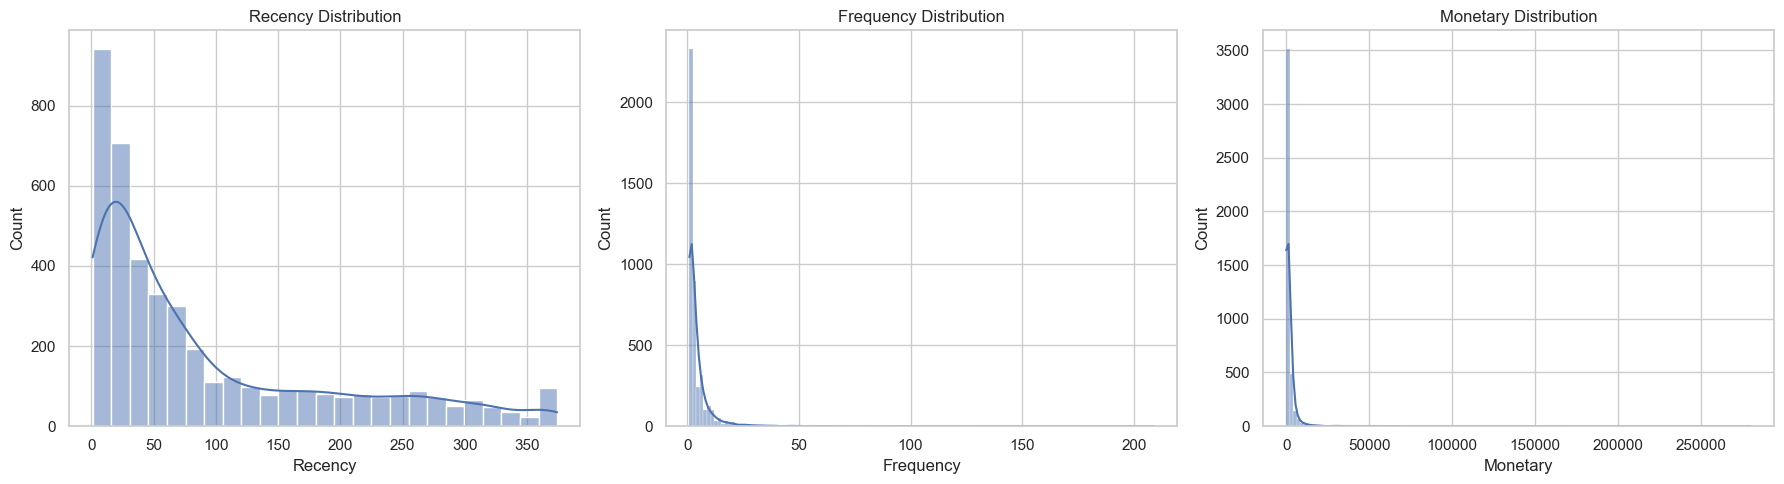

Recency      1.25
Frequency   12.07
Monetary    19.34
Name: Skewness, dtype: float64

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], kde=True, ax=ax)
    ax.set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

display(rfm[["Recency", "Frequency", "Monetary"]].skew().rename("Skewness"))

## 10. Feature Transformation Decision

RFM variables are often right-skewed, especially Frequency and Monetary.

We compare the raw RFM features with a **log1p transformation**:

`log1p(x) = log(1 + x)`

Recency is also transformed here for consistency across the feature space.

### Decision

Use the log-transformed RFM representation for clustering when the transformation materially reduces skewness and remains interpretable. The original RFM table is retained for business reporting; the transformed features are only used for modeling.

In [12]:
model_features = ["Recency", "Frequency", "Monetary"]

rfm_log = rfm[model_features].copy()

for col in model_features:
    rfm_log[col] = np.log1p(rfm_log[col])

skew_comparison = pd.DataFrame({
    "Raw_Skewness": rfm[model_features].skew(),
    "Log1p_Skewness": rfm_log[model_features].skew(),
})

display(skew_comparison)

,Raw_Skewness,Log1p_Skewness
Recency,1.25,-0.38
Frequency,12.07,1.21
Monetary,19.34,0.40


## 11. Scale the Modeling Features

K-Means uses distances, so features must be on comparable scales.

### Decision

Use `StandardScaler` after log transformation so that each RFM feature contributes on a comparable standardized scale.

The scaler will later be persisted together with the K-Means model so that future predictions use exactly the same transformation.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=model_features,
    index=rfm.index
)

display(X_scaled.head())
display(X_scaled.describe().loc[["mean", "std"]])

,Recency,Frequency,Monetary
0,1.46,-0.96,3.71
1,-2.04,1.07,1.41
2,0.37,0.39,0.72
3,-0.62,-0.96,0.70
4,1.42,-0.96,-0.61


,Recency,Frequency,Monetary
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00


## 12. Determine the Number of Clusters

The original notebook used an elbow plot and manually selected `K=3`.

Here we improve that step by evaluating several clustering diagnostics:

- **Inertia:** lower is better, but always decreases as K increases.
- **Silhouette Score:** higher generally indicates better separation.
- **Calinski-Harabasz:** higher generally indicates stronger between-cluster separation relative to within-cluster dispersion.
- **Davies-Bouldin:** lower indicates better separation.

### Decision

No single metric is treated as an automatic truth. We inspect the metrics together and choose a K that provides a reasonable balance of separation, compactness, interpretability, and business usability.

In [14]:
k_values = range(2, 9)
selection_rows = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    labels = model.fit_predict(X_scaled)

    selection_rows.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels),
        "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
    })

model_selection = pd.DataFrame(selection_rows)

display(model_selection.round(4))

,K,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,2,"6,483.59",0.43,"4,367.32",0.89
1,3,"4,869.49",0.34,"3,625.30",1.05
2,4,"3,938.60",0.34,"3,328.92",1.01
3,5,"3,296.71",0.32,"3,192.98",0.99
4,6,"2,855.53",0.31,"3,082.28",1.02
5,7,"2,548.82",0.31,"2,963.79",0.98
6,8,"2,336.34",0.30,"2,827.07",0.99


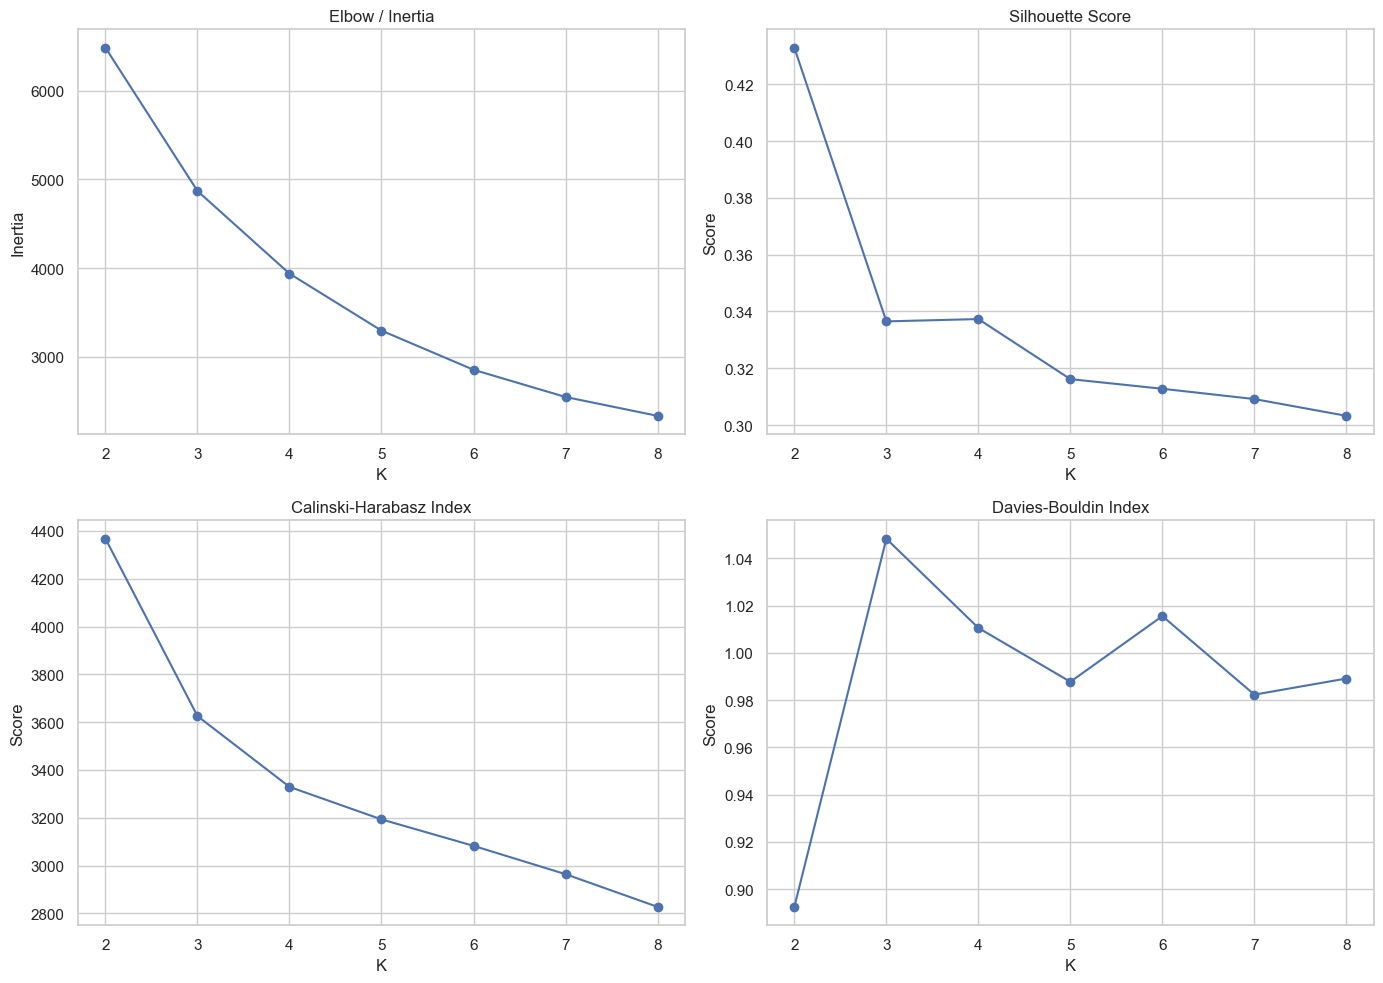

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(model_selection["K"], model_selection["Inertia"], marker="o")
axes[0, 0].set_title("Elbow / Inertia")
axes[0, 0].set_xlabel("K")
axes[0, 0].set_ylabel("Inertia")

axes[0, 1].plot(model_selection["K"], model_selection["Silhouette"], marker="o")
axes[0, 1].set_title("Silhouette Score")
axes[0, 1].set_xlabel("K")
axes[0, 1].set_ylabel("Score")

axes[1, 0].plot(model_selection["K"], model_selection["Calinski_Harabasz"], marker="o")
axes[1, 0].set_title("Calinski-Harabasz Index")
axes[1, 0].set_xlabel("K")
axes[1, 0].set_ylabel("Score")

axes[1, 1].plot(model_selection["K"], model_selection["Davies_Bouldin"], marker="o")
axes[1, 1].set_title("Davies-Bouldin Index")
axes[1, 1].set_xlabel("K")
axes[1, 1].set_ylabel("Score")

plt.tight_layout()
plt.show()

## 13. Select the Final K

The metrics above are now available for inspection.

### Decision rule used in this notebook

Use the K with the **highest Silhouette Score** as the primary statistical criterion, then inspect the other metrics and cluster sizes for plausibility.

> This is a reproducible rule rather than manually forcing `K=3`. If the metric-optimal K produces very small or operationally meaningless groups, reconsider it using the full evidence and document the decision.

In [16]:
best_k_by_silhouette = int(
    model_selection.loc[
        model_selection["Silhouette"].idxmax(), "K"
    ]
)

print("Best K by Silhouette Score:", best_k_by_silhouette)

# Change this only if the diagnostic review above justifies another K.
FINAL_K = best_k_by_silhouette

print("Final K selected:", FINAL_K)

Best K by Silhouette Score: 2
Final K selected: 2


## 14. Train the Final K-Means Model

### Decision

Use:

- the selected `FINAL_K`
- `random_state=42` for reproducibility
- `n_init=20` to reduce dependence on a single initialization

The model is trained on the transformed and standardized RFM feature space.

In [17]:
kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=20
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print("Final model trained.")
display(rfm["Cluster"].value_counts().sort_index())

Final model trained.


Cluster
0    2672
1    1666
Name: count, dtype: int64

## 15. Cluster Size Validation

A clustering solution should not only have good statistical metrics; it should also produce groups that can be meaningfully analyzed.

### Decision

Inspect the number and percentage of customers in every cluster. Extremely tiny clusters may represent niche/high-value customers, outliers, or an unstable solution, so they require explicit interpretation rather than automatic removal.

In [18]:
cluster_size = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customers")
    .to_frame()
)

cluster_size["Percentage"] = (
    cluster_size["Customers"] / len(rfm) * 100
)

display(cluster_size.round(2))

,Customers,Percentage
Cluster,,
0,2672,61.60
1,1666,38.40


## 16. Cluster Profiling

Cluster IDs are arbitrary. Cluster `0` is not inherently "Gold", and cluster `2` is not inherently "Diamond".

We therefore profile the **original business-scale RFM values** first.

### Decision

Segment names will be assigned from the observed RFM profile rather than from arbitrary cluster IDs.

In [19]:
cluster_profile = (
    rfm.groupby("Cluster")[model_features]
    .agg(["mean", "median"])
)

display(cluster_profile.round(2))

Recency        Frequency        Monetary         
           mean median      mean median     mean   median
Cluster                                                  
0        134.09  96.00      1.67   1.00   495.59   363.08
1         25.89  16.00      8.44   6.00 4,539.60 2,061.08

In [20]:
cluster_summary = (
    rfm.groupby("Cluster")[model_features]
    .mean()
    .round(2)
)

cluster_summary["Customers"] = rfm["Cluster"].value_counts()
cluster_summary["Percentage"] = (
    cluster_summary["Customers"] / len(rfm) * 100
)

display(cluster_summary.sort_index())

,Recency,Frequency,Monetary,Customers,Percentage
Cluster,,,,,
0,134.09,1.67,495.59,2672,61.60
1,25.89,8.44,"4,539.60",1666,38.40


## 17. Visualize Cluster Profiles

A heatmap of standardized cluster-level RFM means makes the relative behavioral differences easier to interpret.

### Decision

Use standardized cluster means for visualization, while keeping raw RFM values for business reporting.

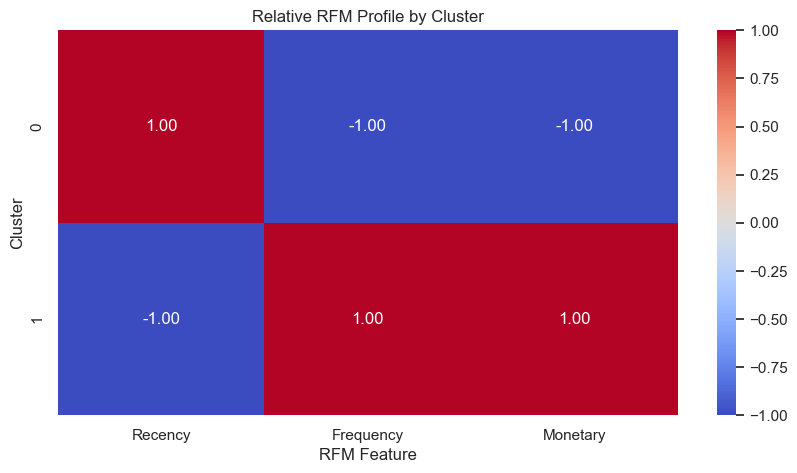

In [21]:
profile_scaled = (
    rfm.groupby("Cluster")[model_features]
    .mean()
)

profile_z = pd.DataFrame(
    StandardScaler().fit_transform(profile_scaled),
    index=profile_scaled.index,
    columns=profile_scaled.columns
)

plt.figure(figsize=(10, 5))
sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Relative RFM Profile by Cluster")
plt.xlabel("RFM Feature")
plt.ylabel("Cluster")
plt.show()

## 18. PCA Visualization

RFM has three dimensions. PCA provides a 2D representation for visual inspection.

### Decision

PCA is used **only for visualization**, not for the final clustering model. The actual K-Means model continues to use all three transformed and standardized RFM features.

Explained variance ratio: [0.75078634 0.18786648]
Total explained variance: 0.9386528181989527


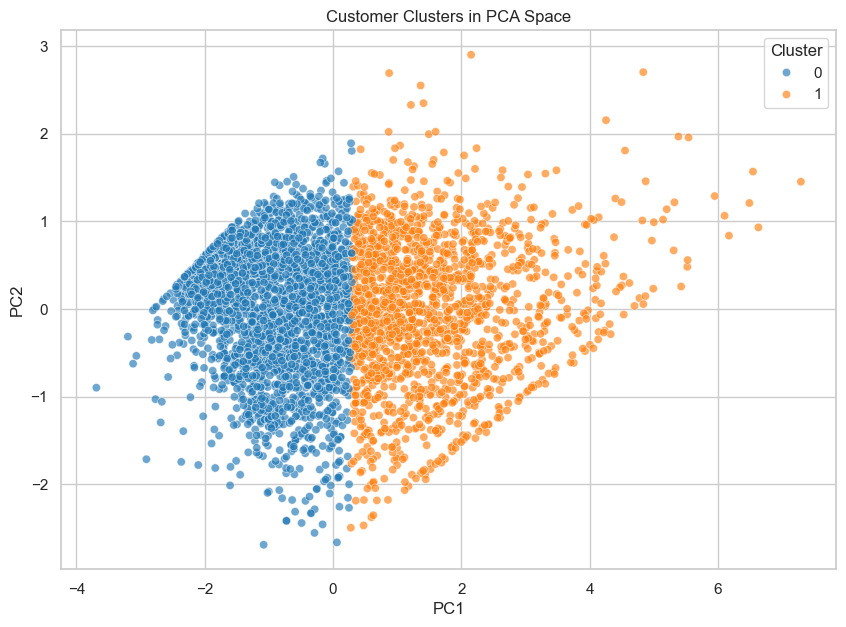

In [22]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=rfm.index
)

pca_df["Cluster"] = rfm["Cluster"].values

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.65
)
plt.title("Customer Clusters in PCA Space")
plt.show()

## 19. Business Segment Naming

Because cluster labels are arbitrary, we derive business segment names from the actual RFM profile.

A simple interpretation framework:

- **High value + frequent + recent:** Champions
- **Strong value/frequency but less recent:** Loyal / At-Risk Loyal
- **Low engagement/value:** Low-Value / At-Risk

### Decision

The exact mapping is created from the observed cluster profile, not hard-coded cluster numbers. The mapping below is therefore a **business interpretation layer**, not part of the statistical K-Means algorithm.

In [23]:
# Rank clusters on business-relevant dimensions.
profile = rfm.groupby("Cluster")[model_features].mean()

# Lower Recency is better; higher Frequency and Monetary are better.
profile["RecencyRank"] = profile["Recency"].rank(ascending=True)
profile["FrequencyRank"] = profile["Frequency"].rank(ascending=False)
profile["MonetaryRank"] = profile["Monetary"].rank(ascending=False)

profile["BusinessScore"] = (
    -profile["RecencyRank"]
    + profile["FrequencyRank"]
    + profile["MonetaryRank"]
)

profile = profile.sort_values("BusinessScore", ascending=False)

display(profile.round(2))

,Recency,Frequency,Monetary,RecencyRank,FrequencyRank,MonetaryRank,BusinessScore
Cluster,,,,,,,
0,134.09,1.67,495.59,2.00,2.00,2.00,2.00
1,25.89,8.44,"4,539.60",1.00,1.00,1.00,1.00


In [24]:
# Create a generic, profile-driven naming scheme.
ordered_clusters = profile.index.tolist()

segment_names = {}

if len(ordered_clusters) == 3:
    segment_names = {
        ordered_clusters[0]: "Champions",
        ordered_clusters[1]: "Loyal Customers",
        ordered_clusters[2]: "At-Risk / Low-Value Customers",
    }
else:
    # For K != 3, retain interpretable generic names rather than pretending
    # that a 3-segment business taxonomy still applies.
    labels = ["Highest-Value Segment", "High-Value Segment",
              "Mid-Value Segment", "Lower-Value Segment",
              "At-Risk Segment", "Low-Value Segment",
              "Niche Segment", "Emerging Segment"]
    segment_names = {
        cluster: labels[i] if i < len(labels) else f"Segment {i+1}"
        for i, cluster in enumerate(ordered_clusters)
    }

rfm["Segment"] = rfm["Cluster"].map(segment_names)

display(rfm["Segment"].value_counts().to_frame("Customers"))

,Customers
Segment,
Highest-Value Segment,2672
High-Value Segment,1666


## 20. Final Segment Profile

This is the main business output of the analytical notebook.

### Interpretation guideline

Do not claim that a segment is "good" or "bad" in isolation. Instead, describe it using measurable behavior:

- recency
- purchase frequency
- monetary contribution
- customer count

These measurable attributes can then support marketing actions.

In [25]:
final_segment_profile = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Median_Recency=("Recency", "median"),
        Avg_Frequency=("Frequency", "mean"),
        Median_Frequency=("Frequency", "median"),
        Avg_Monetary=("Monetary", "mean"),
        Median_Monetary=("Monetary", "median"),
    )
    .sort_values("Avg_Monetary", ascending=False)
)

final_segment_profile["Customer_Percentage"] = (
    final_segment_profile["Customers"] / len(rfm) * 100
)

display(final_segment_profile.round(2))

,Customers,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_Monetary,Median_Monetary,Customer_Percentage
Segment,,,,,,,,
High-Value Segment,1666,25.89,16.00,8.44,6.00,"4,539.60","2,061.08",38.40
Highest-Value Segment,2672,134.09,96.00,1.67,1.00,495.59,363.08,61.60


## 21. Segment Distribution

### Decision

Report both counts and percentages. Customer count alone can hide the relative size of a segment.

,Segment,Customers,Percentage
0,Highest-Value Segment,2672,61.60
1,High-Value Segment,1666,38.40


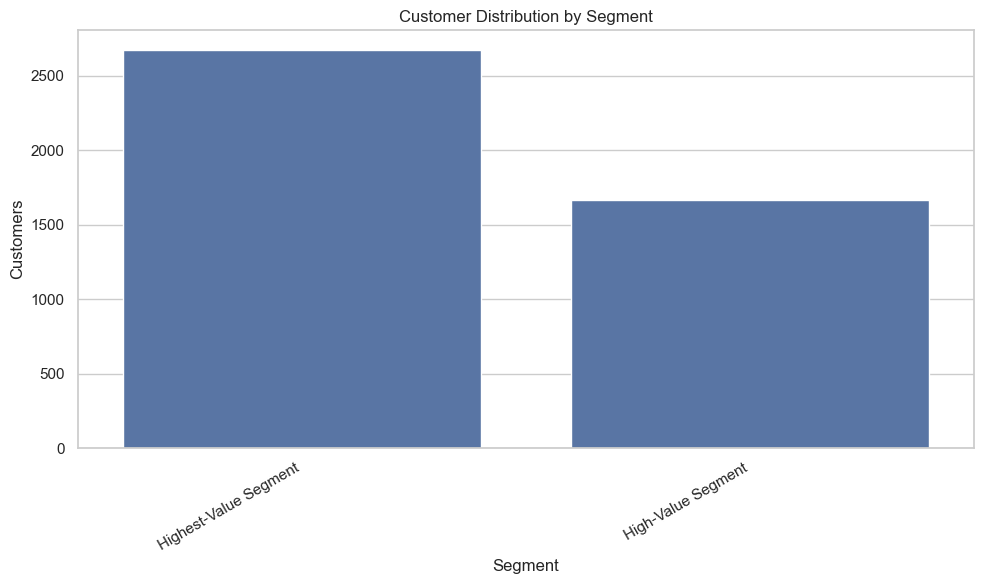

In [26]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customers")
)

segment_counts["Percentage"] = (
    segment_counts["Customers"] / len(rfm) * 100
)

display(segment_counts.round(2))

plt.figure(figsize=(10, 6))
sns.barplot(data=segment_counts, x="Segment", y="Customers")
plt.xticks(rotation=30, ha="right")
plt.title("Customer Distribution by Segment")
plt.tight_layout()
plt.show()

## 22. Business Interpretation

The model identifies behavioral groups; it does **not** directly prove why customers behave differently.

### Recommended interpretation framework

| Observable profile | Potential business use |
|---|---|
| Recent + frequent + high monetary | VIP/loyalty programs, cross-sell, retention |
| Frequent + moderate value | Loyalty development and upsell |
| Low recency + historically valuable | Re-engagement / win-back campaigns |
| Low frequency + low monetary | Low-cost targeted communication |

### Decision

Marketing actions should be validated experimentally. Segmentation is an analytical tool, not evidence that a particular campaign will definitely improve revenue.

## 23. Model Validation Summary

Capture the final K and its diagnostic scores for reproducibility.

In [27]:
final_metrics = model_selection.loc[
    model_selection["K"] == FINAL_K
].iloc[0]

print(f"Final K: {FINAL_K}")
print(f"Inertia: {final_metrics['Inertia']:.4f}")
print(f"Silhouette: {final_metrics['Silhouette']:.4f}")
print(f"Calinski-Harabasz: {final_metrics['Calinski_Harabasz']:.4f}")
print(f"Davies-Bouldin: {final_metrics['Davies_Bouldin']:.4f}")

Final K: 2
Inertia: 6483.5894
Silhouette: 0.4328
Calinski-Harabasz: 4367.3231
Davies-Bouldin: 0.8925


## 24. Export Analytical Results

### Decision

The notebook exports the customer-level segmentation and cluster-level summaries so that downstream applications such as Streamlit or Power BI do not need to rerun exploratory analysis.

In [28]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

rfm_export = rfm.copy()

rfm_export.to_csv(
    OUTPUT_DIR / "customer_segments.csv",
    index=False
)

final_segment_profile.to_csv(
    OUTPUT_DIR / "segment_profile.csv"
)

model_selection.to_csv(
    OUTPUT_DIR / "model_selection_metrics.csv",
    index=False
)

cluster_summary.to_csv(
    OUTPUT_DIR / "cluster_rfm_summary.csv"
)

print(f"Exports saved to: {OUTPUT_DIR.resolve()}")

Exports saved to: C:\Users\mdnay\Desktop\My_Code\Projects\project 4\outputs


## 25. Save the Trained Model Artifacts

### Decision

Persist both the scaler and K-Means model. Future predictions must apply the **same log transformation and fitted scaler** used during training.

The transformation specification is saved as metadata so the production application can reproduce the training process.

In [29]:
import joblib
import json

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(
    scaler,
    ARTIFACT_DIR / "rfm_scaler.joblib"
)

joblib.dump(
    kmeans,
    ARTIFACT_DIR / "kmeans_model.joblib"
)

metadata = {
    "features": model_features,
    "transformation": "log1p",
    "scaling": "StandardScaler",
    "algorithm": "KMeans",
    "n_clusters": int(FINAL_K),
    "random_state": RANDOM_STATE,
    "reference_date": str(reference_date),
    "segment_mapping": {str(k): v for k, v in segment_names.items()},
}

with open(ARTIFACT_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


## 26. Final Sanity Check

Before considering the analytical notebook complete:

- RFM contains no invalid values.
- Every customer has a cluster.
- Every cluster has a business segment.
- Model artifacts exist.
- Output tables exist.

### Final Decision

If all checks pass, the analytical notebook is complete. The next project layer is the production application (`src/` + Streamlit), which should load these artifacts rather than duplicate the notebook's exploratory logic.

In [30]:
assert len(rfm) > 0
assert rfm["Cluster"].notna().all()
assert rfm["Segment"].notna().all()

required_artifacts = [
    ARTIFACT_DIR / "rfm_scaler.joblib",
    ARTIFACT_DIR / "kmeans_model.joblib",
    ARTIFACT_DIR / "metadata.json",
    OUTPUT_DIR / "customer_segments.csv",
    OUTPUT_DIR / "segment_profile.csv",
    OUTPUT_DIR / "model_selection_metrics.csv",
]

missing = [str(p) for p in required_artifacts if not p.exists()]

if missing:
    raise FileNotFoundError(f"Missing artifacts: {missing}")

print("✅ Final sanity checks passed.")
print("✅ Analytical notebook is complete.")
print("➡️ Next: connect the saved artifacts to the production pipeline and Streamlit app.")

✅ Final sanity checks passed.
✅ Analytical notebook is complete.
➡️ Next: connect the saved artifacts to the production pipeline and Streamlit app.


# Final Project Decision Log

### What changed from the original notebook?

1. Added explicit data-quality auditing.
2. Removed cancellations from modeling data.
3. Removed invalid quantity and price records.
4. Removed missing customer IDs.
5. Added duplicate handling.
6. Used a data-driven reference date.
7. Defined Frequency using distinct invoices.
8. Added RFM quality checks.
9. Added distribution and skewness analysis.
10. Added log transformation before clustering.
11. Added standardized modeling features.
12. Replaced a manual K=3 assumption with multi-metric K evaluation.
13. Added reproducible K-Means configuration.
14. Added cluster-size analysis.
15. Added cluster profiling.
16. Added PCA visualization.
17. Removed hard-coded cluster-ID-to-segment assumptions.
18. Added business segment interpretation.
19. Exported customer-level and segment-level results.
20. Saved the scaler and K-Means model artifacts.
21. Added a final reproducibility/sanity check.

### Important methodological note

The clustering model is unsupervised. Segment labels such as `Champions` or `Loyal Customers` are business interpretations of the resulting behavioral profiles; they are not ground-truth labels learned from the data.

### Production boundary

This notebook is the **complete analytical notebook**. The final repository should additionally contain:

```text
src/
├── preprocessing
├── training
└── prediction

app.py
requirements.txt
README.md
tests/
```

The Streamlit application should load the saved artifacts and should not depend on executing the entire notebook.